## SubGraph
### Not Keeping routing intent in LangGraph state

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# openai_llm.invoke("what is 2+2").content

In [2]:
# Basic LangGraph imports

from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
from pydantic import BaseModel, Field
from typing import Literal, List
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

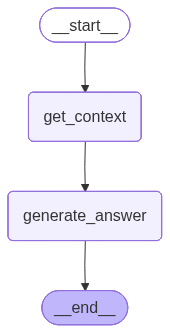

In [3]:
# RAG SubGraph

class RagState(MessagesState):
    pass

def get_context(state: MessagesState):
    pass

def generate_answer(state: MessagesState):
    pass

rag_builder = StateGraph(RagState)

rag_builder.add_node("get_context", get_context)
rag_builder.add_node("generate_answer", generate_answer)

rag_builder.add_edge(START, "get_context")
rag_builder.add_edge("get_context", "generate_answer")
rag_builder.add_edge("generate_answer", END)

rag_graph = rag_builder.compile()


display(Image(rag_graph.get_graph().draw_mermaid_png()))


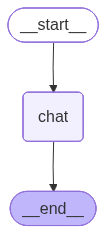

In [4]:
# Normal chat SubGraph

class ChatState(MessagesState):
    pass

def chat(state: MessagesState):
    res = openai_llm.invoke(state["messages"])
    return {"messages": res}

chat_builder = StateGraph(ChatState)

chat_builder.add_node("chat", chat)

chat_builder.add_edge(START, "chat")
chat_builder.add_edge("chat", END)

chat_graph = chat_builder.compile()

display(Image(chat_graph.get_graph().draw_mermaid_png()))



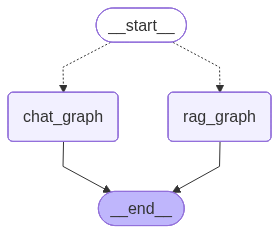

In [ ]:
# RAG Parentgraph build


class MainState(MessagesState):
    pass


class RouteIntent(BaseModel):
    is_rag: bool = Field(description="True if the user is asking about specific document details, policies, storage limits, accounts, or specs. False for general chit-chat.")


# def route_node(state: MessagesState):
#     return {"messages": []}


def find_intent(state: MainState) -> Literal["rag_graph", "chat_graph"]:
    
    last_message = state["messages"][-1].content
    structured_llm = openai_llm.with_structured_output(RouteIntent)
    
    decision = structured_llm.invoke(last_message)
    
    log_record = {
        "user_query": last_message,
        "is_rag_detected": decision.is_rag
    }
    
    target_route = "rag_graph" if decision.is_rag else "chat_graph"
    
    print(f"[Router] Routing to: {target_route}")
    
    # from langgraph.types import Command
    # return Command(
    #     update={"intent_history": [log_record]}, # Appends to state channel automatically
    #     goto=target_route                        # Selects next execution node
    # )

    return target_route


main_builder = StateGraph(MainState)

main_builder.add_node("rag_graph", rag_graph)
main_builder.add_node("chat_graph", chat_graph)


main_builder.add_conditional_edges(START, find_intent)
main_builder.add_edge("rag_graph", END)
main_builder.add_edge("chat_graph", END)

main_graph = main_builder.compile()

display(Image(main_graph.get_graph().draw_mermaid_png()))


In [8]:
res = main_graph.invoke({"messages": HumanMessage(content="What is IPL?")})

res

 -> [Router] Query evaluated. Saving log context. Routing to: chat_graph


{'messages': [HumanMessage(content='What is IPL?', additional_kwargs={}, response_metadata={}, id='83ec896f-2443-427b-8391-83673dbe4b35'),
  AIMessage(content='"IPL" can mean different things depending on context. Do you mean:\n\n- Indian Premier League — a professional Twenty20 cricket league in India (founded 2008), contested by city-based franchises each season, known for player auctions, high TV viewership and short-format matches.\n- Intense Pulsed Light — a dermatology/cosmetic treatment that uses broad-spectrum light (not a laser) for hair removal, photorejuvenation, treating pigmentation, vascular lesions and acne; has different risks/effectiveness than lasers.\n- Initial Program Load (or Initial Program Loader) — a computing/mainframe term for the bootstrapping process that loads the operating system at startup.\n\nIf you tell me which one you mean, I can give more detail (how it works, history, pros/cons, current season/teams, etc.).', additional_kwargs={'refusal': None}, res